## 1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download("SPY", start="2021-02-01", end="2026-07-31",
                   auto_adjust=True, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[["Close"]]
data.index = pd.to_datetime(data.index).tz_localize(None)

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))
data = data.dropna()

returns = data["log_return"]
delta = 1 / 252
lookback = 100
decay = 0.94

plot_window = (returns.index >= "2021-08-01") & (returns.index <= "2026-07-30")

## (a) 

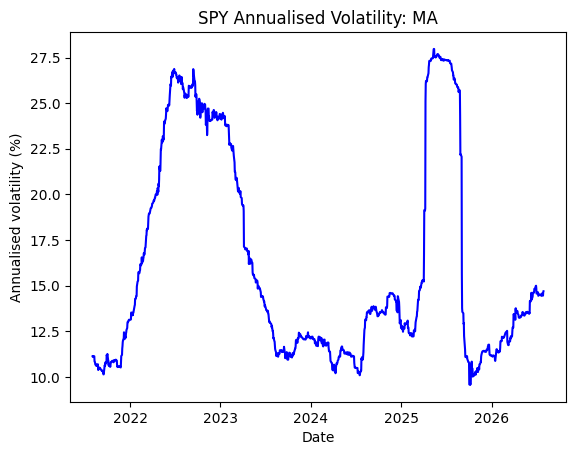

In [2]:
ma_variance = returns.rolling(lookback).var(ddof=1)
ma_vol = np.sqrt(ma_variance / delta)

plt.figure()
plt.plot(ma_vol[plot_window].index, ma_vol[plot_window] * 100, color="blue")
plt.title("SPY Annualised Volatility: MA")
plt.xlabel("Date")
plt.ylabel("Annualised volatility (%)")
plt.show()

## (b) 

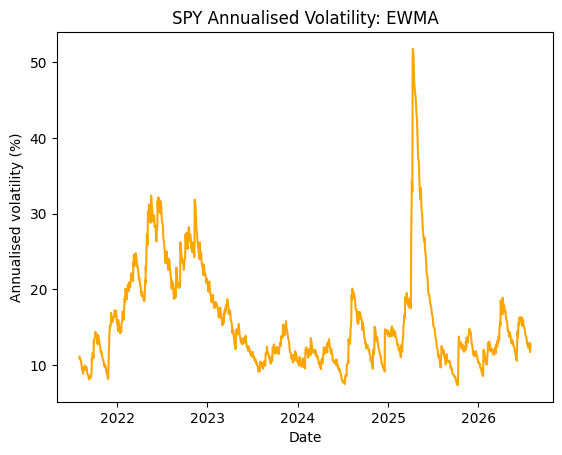

In [3]:
ewma_variance = ma_variance * np.nan
seed_day = lookback - 1
ewma_variance.iloc[seed_day] = ma_variance.iloc[seed_day]

for day in range(seed_day, len(returns) - 1):
    previous = ewma_variance.iloc[day]
    squared_return = returns.iloc[day] ** 2
    ewma_variance.iloc[day + 1] = decay * previous + (1 - decay) * squared_return

ewma_vol = np.sqrt(ewma_variance / delta)

plt.figure()
plt.plot(ewma_vol[plot_window].index, ewma_vol[plot_window] * 100, color="orange")
plt.title("SPY Annualised Volatility: EWMA")
plt.xlabel("Date")
plt.ylabel("Annualised volatility (%)")
plt.show()

### Combined

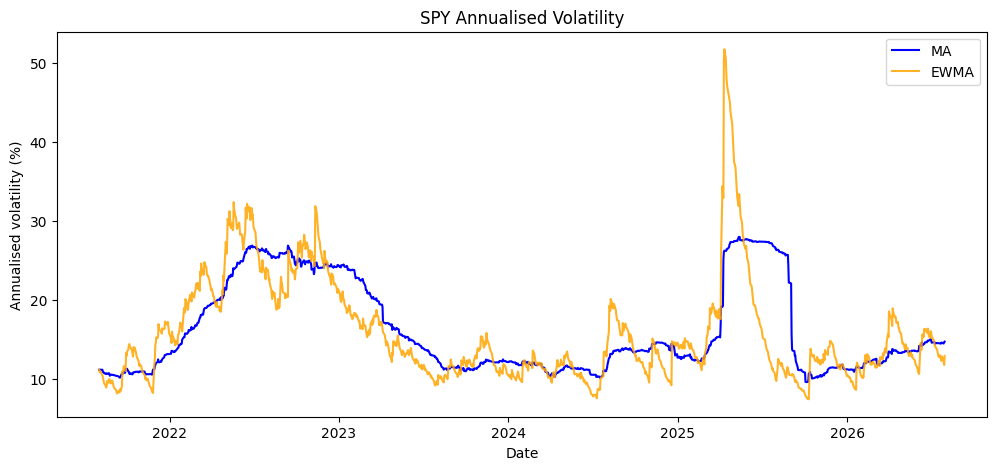

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ma_vol[plot_window].index, ma_vol[plot_window] * 100,
         color="blue", label="MA")
plt.plot(ewma_vol[plot_window].index, ewma_vol[plot_window] * 100,
         color="orange", alpha=0.85, label="EWMA")
plt.title("SPY Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised volatility (%)")
plt.legend()
plt.show()

## 2.

In [5]:
from scipy.optimize import minimize

fit_window = (returns.index >= "2025-06-01") & (returns.index <= "2026-05-31")
fit_returns = returns[fit_window].values * 100


def variance_path(a0, a1, b1):
    v = np.var(fit_returns, ddof=1)
    path = []
    for r in fit_returns:
        path.append(v)
        v = a0 + a1 * r ** 2 + b1 * v
    return np.array(path)


def score(params):
    a0, a1, b1 = params
    if a0 <= 0 or a1 < 0 or b1 < 0 or a1 + b1 >= 1:
        return 1e10
    v = variance_path(a0, a1, b1)
    return np.sum(np.log(v) + fit_returns ** 2 / v)


guess = (0.05 * np.var(fit_returns, ddof=1), 0.06, 0.88)
result = minimize(score, guess, method="Nelder-Mead",
                  options={"maxiter": 20000, "xatol": 1e-10, "fatol": 1e-10})

a0 = result.x[0] / 10000
a1 = result.x[1]
b1 = result.x[2]

In [6]:
persistence = a1 + b1
long_run_variance = a0 / (1 - persistence)
long_run_vol = np.sqrt(long_run_variance / delta)

fitted_variance = variance_path(*result.x) / 10000
last_variance = fitted_variance[-1]

print("a0 in millionths:", round(a0 * 1e6, 4))
print("a1:", round(a1, 6))
print("b1:", round(b1, 6))
print("persistence:", round(persistence, 6))
print("long run volatility, annualised percent:", round(long_run_vol * 100, 2))

a0 in millionths: 6.893
a1: 0.054575
b1: 0.824222
persistence: 0.878797
long run volatility, annualised percent: 11.97


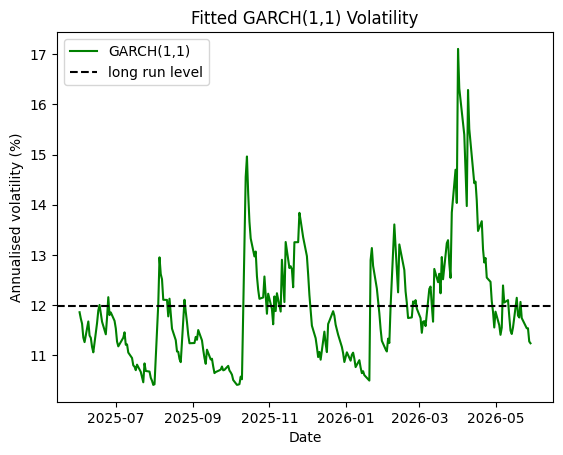

In [7]:
plt.figure()
plt.plot(returns[fit_window].index, np.sqrt(fitted_variance / delta) * 100,
         color="green", label="GARCH(1,1)")
plt.axhline(long_run_vol * 100, color="black", linestyle="--",
            label="long run level")
plt.title("Fitted GARCH(1,1) Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised volatility (%)")
plt.legend()
plt.show()

## 3.

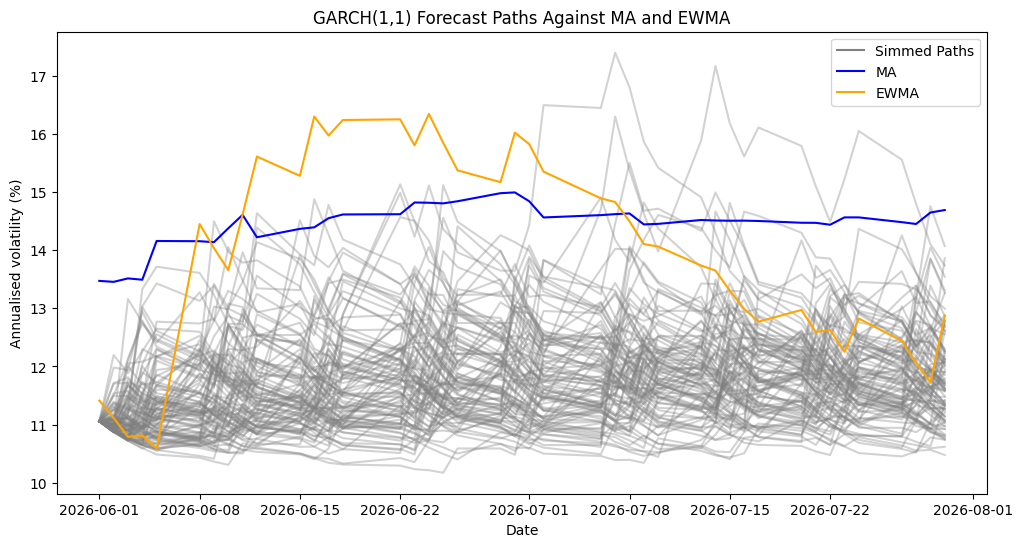

forecast days: 42  paths: 100
share of days and paths where the realised MA sits above our path:  98.9 %


In [8]:
forecast_window = (returns.index >= "2026-06-01") & (returns.index <= "2026-07-30")
forecast_days = int(forecast_window.sum())
num_paths = 100

last_return = returns[fit_window].iloc[-1]
first_variance = a0 + a1 * last_return ** 2 + b1 * last_variance

rng = np.random.default_rng(42)
variance = np.full(num_paths, first_variance)
path_vol = np.zeros((num_paths, forecast_days))

for day in range(forecast_days):
    path_vol[:, day] = np.sqrt(variance / delta)
    shock = rng.standard_normal(num_paths)
    simulated_return = np.sqrt(variance) * shock
    variance = a0 + a1 * simulated_return ** 2 + b1 * variance

plt.figure(figsize=(12, 6))
plt.plot(returns[forecast_window].index, path_vol.T * 100, color="grey", alpha=0.35)
plt.plot([], [], color="grey", label="Simmed Paths")
plt.plot(returns[forecast_window].index, ma_vol[forecast_window] * 100,
         color="blue", label="MA")
plt.plot(returns[forecast_window].index, ewma_vol[forecast_window] * 100,
         color="orange", label="EWMA")
plt.title("GARCH(1,1) Forecast Paths Against MA and EWMA")
plt.xlabel("Date")
plt.ylabel("Annualised volatility (%)")
plt.legend()
plt.show()

print("forecast days:", forecast_days, " paths:", num_paths)
print("share of days and paths where the realised MA sits above our path: ",
      round((ma_vol[forecast_window].values[:, None] > path_vol.T).mean() * 100, 1), "%")